# Importing Libraries

In [63]:
SEED = 1

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401 (untuk compatibility lama)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
np.random.seed(SEED)



In [64]:
!pip -q install kaggle
from google.colab import files
files.upload()  # pilih file kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"faizahviafadhillah","key":"2fb3d03e40698d4cca52b050764fcc28"}'}

In [65]:
# pasang kredensial
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [66]:
# download & unzip dataset target (sesuai instruksi dospem)
!kaggle datasets download -d mayank1897/condition-monitoring-of-hydraulic-systems -p /content/data -q
!unzip -q /content/data/condition-monitoring-of-hydraulic-systems.zip -d /content/data

# set base folder
BASE_DIR = "/content/data/condition-monitoring-of-hydraulic-systems"
import os, glob, pathlib
txts = sorted(glob.glob(BASE_DIR + "/*.txt"))
len(txts), [pathlib.Path(p).name for p in txts[:20]]

Dataset URL: https://www.kaggle.com/datasets/mayank1897/condition-monitoring-of-hydraulic-systems
License(s): other
replace /content/data/CE.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/CP.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/EPS1.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/FS1.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/FS2.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/PS1.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/PS2.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/PS3.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/PS4.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/PS5.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/PS6.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/SE.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/TS1.txt? [y]

(0, [])

In [67]:
BASE_DIR = "/content/data"   # folder yang berisi PS1.txt, PS2.txt, ... (di kiri sudah terlihat benar)

files = ["PS1","PS2","PS3","PS4","PS5","PS6"]
temp = []

for nm in files:
    fp = os.path.join(BASE_DIR, f"{nm}.txt")  # bentuk path yang benar: /content/data/PS1.txt
    arr = np.genfromtxt(fp)
    temp.append(arr)

len(temp), temp[0].shape

(6, (2205, 6000))

In [68]:
for v in ["name", "i"]:
    if v in globals():
        del globals()[v]

In [69]:
BASE_DIR = "/content/data"
paths = sorted(glob.glob(os.path.join(BASE_DIR, "PS[1-6].txt")))  # PS1..PS6
temp = [np.genfromtxt(p) for p in paths]
len(temp), os.path.basename(paths[0])


(6, 'PS1.txt')

# Constructing Dataset

#### Pressure Sensor Data

In [70]:
temp=[]
lis1 = ["PS1","PS2","PS3","PS4","PS5","PS6"]
for i in lis1:
    dataPS = np.genfromtxt(os.path.join (BASE_DIR, f"{nm}.txt"))
    temp.append(dataPS)
temp

[array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
        [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]]),
 array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
        [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]]),
 array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.8

In [71]:
# unpacking data from temp
ps1,ps2,ps3,ps4,ps5,ps6=temp

ps1_arr=ps1.mean(axis=1)
ps2_arr=ps2.mean(axis=1)
ps3_arr=ps3.mean(axis=1)
ps4_arr=ps4.mean(axis=1)
ps5_arr=ps5.mean(axis=1)
ps6_arr=ps6.mean(axis=1)

In [72]:
# create a dictionary
data_PS={'PS1':ps1_arr,'PS2':ps2_arr,'PS3':ps3_arr,'PS4':ps4_arr,'PS5':ps5_arr,'PS6':ps6_arr}
df1=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df1['PS1'] = df1['PS1'].round(2)
df1['PS2'] = df1['PS2'].round(2)
df1['PS3'] = df1['PS3'].round(2)
df1['PS4'] = df1['PS4'].round(2)
df1['PS5'] = df1['PS5'].round(2)
df1['PS6'] = df1['PS6'].round(2)
df1.head()

,PS1,PS2,PS3,PS4,PS5,PS6
0,9.73,9.73,9.73,9.73,9.73,9.73
1,9.53,9.53,9.53,9.53,9.53,9.53
2,9.43,9.43,9.43,9.43,9.43,9.43
3,9.34,9.34,9.34,9.34,9.34,9.34
4,9.26,9.26,9.26,9.26,9.26,9.26


#### Motor power Sensor Data

In [73]:
# Extract data from the text file
eps1 = np.genfromtxt(os.path.join (BASE_DIR, f"{nm}.txt"))
eps1_arr = eps1.mean(axis=1)

In [74]:
data_PS={'EPS1':eps1_arr}
df2=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df2['EPS1'] = df2['EPS1'].round(2)
df2.head()

,EPS1
0,9.73
1,9.53
2,9.43
3,9.34
4,9.26


#### Volume flow Data

In [75]:
temp2=[]
lis2 = ["FS1","FS2"]
for i in lis2:
    dataPS = np.genfromtxt(os.path.join (BASE_DIR, f"{nm}.txt"))
    temp2.append(dataPS)
temp2

[array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
        [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]]),
 array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
        [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]])]

In [76]:
# unpacking data from temp
fs1,fs2 = temp2

fs1_arr=fs1.mean(axis=1)
fs2_arr=fs2.mean(axis=1)

In [77]:
# create a dictionary
data_PS={'FS1':fs1_arr,'FS2':fs2_arr}
df3=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df3['FS1'] = df3['FS1'].round(2)
df3['FS2'] = df3['FS2'].round(2)
df3.head()

,FS1,FS2
0,9.73,9.73
1,9.53,9.53
2,9.43,9.43
3,9.34,9.34
4,9.26,9.26


#### Temperature Data

In [78]:
temp3=[]
lis3 = ["TS1","TS2","TS3","TS4"]
for i in lis3:
    dataPS = np.genfromtxt(os.path.join (BASE_DIR, f"{nm}.txt"))
    temp3.append(dataPS)
temp3

[array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
        [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]]),
 array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
        [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]]),
 array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
        [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
        [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
        ...,
        [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
        [9.858, 9.84 , 9.828, ..., 9.851, 9.8

In [79]:
# unpacking data from temp
ts1,ts2,ts3,ts4 = temp3

ts1_arr = ts1.mean(axis=1)
ts2_arr = ts2.mean(axis=1)
ts3_arr = ts3.mean(axis=1)
ts4_arr = ts4.mean(axis=1)

In [80]:
# create a dictionary
data_PS={'TS1':ts1_arr,'TS2':ts2_arr,'TS3':ts3_arr,'TS4':ts4_arr}
df4=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df4['TS1'] = df4['TS1'].round(2)
df4['TS2'] = df4['TS2'].round(2)
df4['TS3'] = df4['TS3'].round(2)
df4['TS4'] = df4['TS4'].round(2)
df4.head()

,TS1,TS2,TS3,TS4
0,9.73,9.73,9.73,9.73
1,9.53,9.53,9.53,9.53
2,9.43,9.43,9.43,9.43
3,9.34,9.34,9.34,9.34
4,9.26,9.26,9.26,9.26


#### Vibration Data

In [81]:
# Extract data from the text file
vs1 = np.genfromtxt(os.path.join (BASE_DIR, f"{nm}.txt"))
vs1_arr = vs1.mean(axis=1)

In [82]:
data_PS={'VS1':vs1_arr}
df5=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df5['VS1'] = df5['VS1'].round(2)
df5.head()

,VS1
0,9.73
1,9.53
2,9.43
3,9.34
4,9.26


#### Cooling efficiency Data

In [83]:
# Extract data from the text file
ce = np.genfromtxt(os.path.join(BASE_DIR, f"{nm}.txt"))
ce_arr = ce.mean(axis=1)

In [84]:
data_PS={'CE':ce_arr}
df6=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df6['CE'] = df6['CE'].round(2)
df6.head()

,CE
0,9.73
1,9.53
2,9.43
3,9.34
4,9.26


#### Cooling power Data

In [85]:
# Extract data from the text file
cp = np.genfromtxt(os.path.join(BASE_DIR, f"{nm}.txt"))
cp_arr = cp.mean(axis=1)

In [86]:
data_PS={'CP':cp_arr}
df7=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df7['CP'] = df7['CP'].round(2)
df7.head()

,CP
0,9.73
1,9.53
2,9.43
3,9.34
4,9.26


#### Efficiency factor Data

In [87]:
# Extract data from the text file
se = np.genfromtxt(os.path.join(BASE_DIR, f"{nm}.txt"))
se_arr = se.mean(axis=1)

In [88]:
data_PS={'SE':se_arr}
df8=pd.DataFrame(data_PS)

# Round values to 2 decimal places
df8['SE'] = df8['SE'].round(2)
df8.head()

,SE
0,9.73
1,9.53
2,9.43
3,9.34
4,9.26


In [89]:
# Combine all the dataframes together to create the sensor dataset
sensor_df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], axis=1)
sensor_df.head(10)

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE
0,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73
1,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53
2,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43
3,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34
4,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26
5,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21,9.21
6,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14,9.14
7,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11,9.11
8,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06,9.06
9,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02,9.02


##### So, above is basically the sensor dataset

#### Creating the Factors Dataset around which we predict whether to do maintenance of machine or not

In [90]:
factors_arr=np.genfromtxt(os.path.join(BASE_DIR, f"{nm}.txt"))
factors_arr

array([[9.818, 9.823, 9.844, ..., 9.639, 9.634, 9.615],
       [9.592, 9.573, 9.578, ..., 9.519, 9.526, 9.517],
       [9.505, 9.484, 9.476, ..., 9.382, 9.402, 9.423],
       ...,
       [9.856, 9.873, 9.873, ..., 9.856, 9.866, 9.87 ],
       [9.858, 9.84 , 9.828, ..., 9.851, 9.836, 9.842],
       [9.849, 9.87 , 9.887, ..., 9.886, 9.87 , 9.854]])

In [91]:
print("No. of rows:", factors_arr.shape[0])
print("No. of columns:", factors_arr.shape[1])

No. of rows: 2205
No. of columns: 6000


In [92]:
factors_arr = np.genfromtxt(os.path.join(BASE_DIR, "profile.txt"))
factors_df=pd.DataFrame(factors_arr[:, :4], columns=['Cooler_condition','Valve_condition','Internal_pump_leakage','Hydraulic_accumulator/bar'])
# Calculate Stable_flag based on the conditions (common for this dataset)
factors_df['Stable_flag'] = ((factors_df['Cooler_condition'] == 100) &
                             (factors_df['Valve_condition'] == 100) &
                             (factors_df['Internal_pump_leakage'] == 0) &
                             (factors_df['Hydraulic_accumulator/bar'] == 130)).astype(int)
factors_df.head()

,Cooler_condition,Valve_condition,Internal_pump_leakage,Hydraulic_accumulator/bar,Stable_flag
0,3.0,100.0,0.0,130.0,0
1,3.0,100.0,0.0,130.0,0
2,3.0,100.0,0.0,130.0,0
3,3.0,100.0,0.0,130.0,0
4,3.0,100.0,0.0,130.0,0


In [93]:
# Final dataset
df = pd.concat([sensor_df, factors_df], axis=1)
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,...,TS4,VS1,CE,CP,SE,Cooler_condition,Valve_condition,Internal_pump_leakage,Hydraulic_accumulator/bar,Stable_flag
0,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,9.73,...,9.73,9.73,9.73,9.73,9.73,3.0,100.0,0.0,130.0,0
1,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,9.53,...,9.53,9.53,9.53,9.53,9.53,3.0,100.0,0.0,130.0,0
2,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,9.43,...,9.43,9.43,9.43,9.43,9.43,3.0,100.0,0.0,130.0,0
3,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,9.34,...,9.34,9.34,9.34,9.34,9.34,3.0,100.0,0.0,130.0,0
4,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,9.26,...,9.26,9.26,9.26,9.26,9.26,3.0,100.0,0.0,130.0,0


In [94]:
df.columns

Index(['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1', 'FS1', 'FS2', 'TS1',
       'TS2', 'TS3', 'TS4', 'VS1', 'CE', 'CP', 'SE', 'Cooler_condition',
       'Valve_condition', 'Internal_pump_leakage', 'Hydraulic_accumulator/bar',
       'Stable_flag'],
      dtype='object')

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PS1                        2205 non-null   float64
 1   PS2                        2205 non-null   float64
 2   PS3                        2205 non-null   float64
 3   PS4                        2205 non-null   float64
 4   PS5                        2205 non-null   float64
 5   PS6                        2205 non-null   float64
 6   EPS1                       2205 non-null   float64
 7   FS1                        2205 non-null   float64
 8   FS2                        2205 non-null   float64
 9   TS1                        2205 non-null   float64
 10  TS2                        2205 non-null   float64
 11  TS3                        2205 non-null   float64
 12  TS4                        2205 non-null   float64
 13  VS1                        2205 non-null   float

# Data Visualization

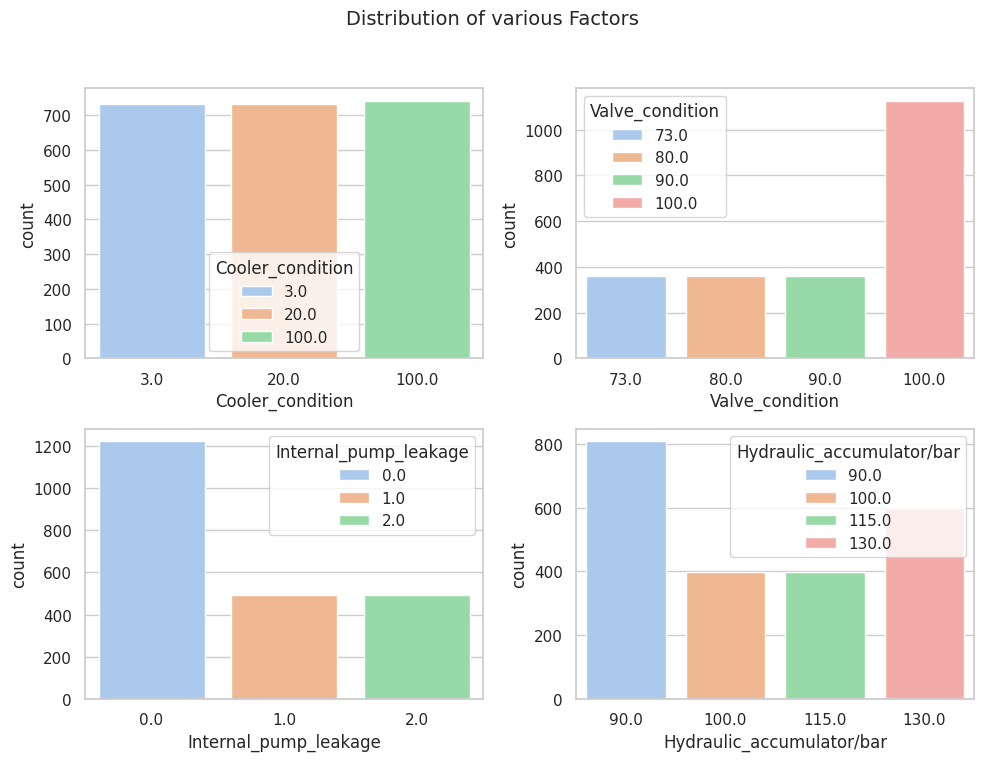

In [96]:
# install sekali jika perlu:
# !pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Distribution of various Factors', fontsize=14)

sns.countplot(x='Cooler_condition', hue='Cooler_condition', data=df, palette='pastel', ax=axes[0, 0])
sns.countplot(x='Valve_condition', hue='Valve_condition', data=df, palette='pastel', ax=axes[0, 1])
sns.countplot(x='Internal_pump_leakage', hue='Internal_pump_leakage', data=df, palette='pastel', ax=axes[1, 0])
sns.countplot(x='Hydraulic_accumulator/bar', hue='Hydraulic_accumulator/bar', data=df, palette='pastel', ax=axes[1, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


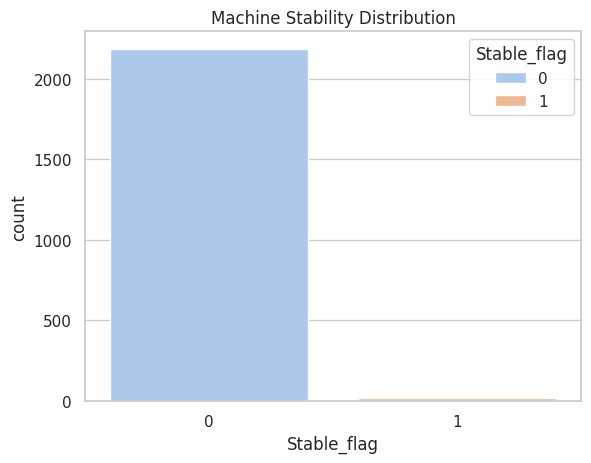

In [97]:
plt.title('Machine Stability Distribution')
sns.countplot(x='Stable_flag', hue='Stable_flag', data=df, palette='pastel')
plt.show()

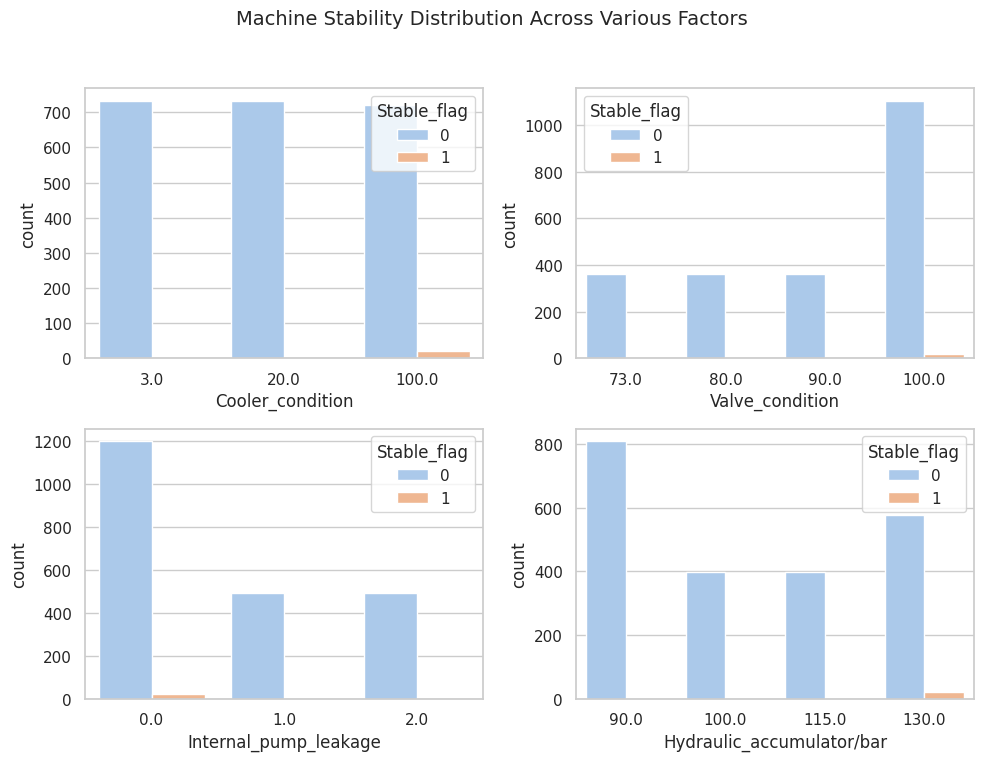

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Machine Stability Distribution Across Various Factors', fontsize=14)

sns.countplot(x='Cooler_condition', hue='Stable_flag', data=df, palette='pastel', ax=axes[0, 0])
sns.countplot(x='Valve_condition', hue='Stable_flag', data=df, palette='pastel', ax=axes[0, 1])
sns.countplot(x='Internal_pump_leakage', hue='Stable_flag', data=df, palette='pastel', ax=axes[1, 0])
sns.countplot(x='Hydraulic_accumulator/bar', hue='Stable_flag', data=df, palette='pastel', ax=axes[1, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

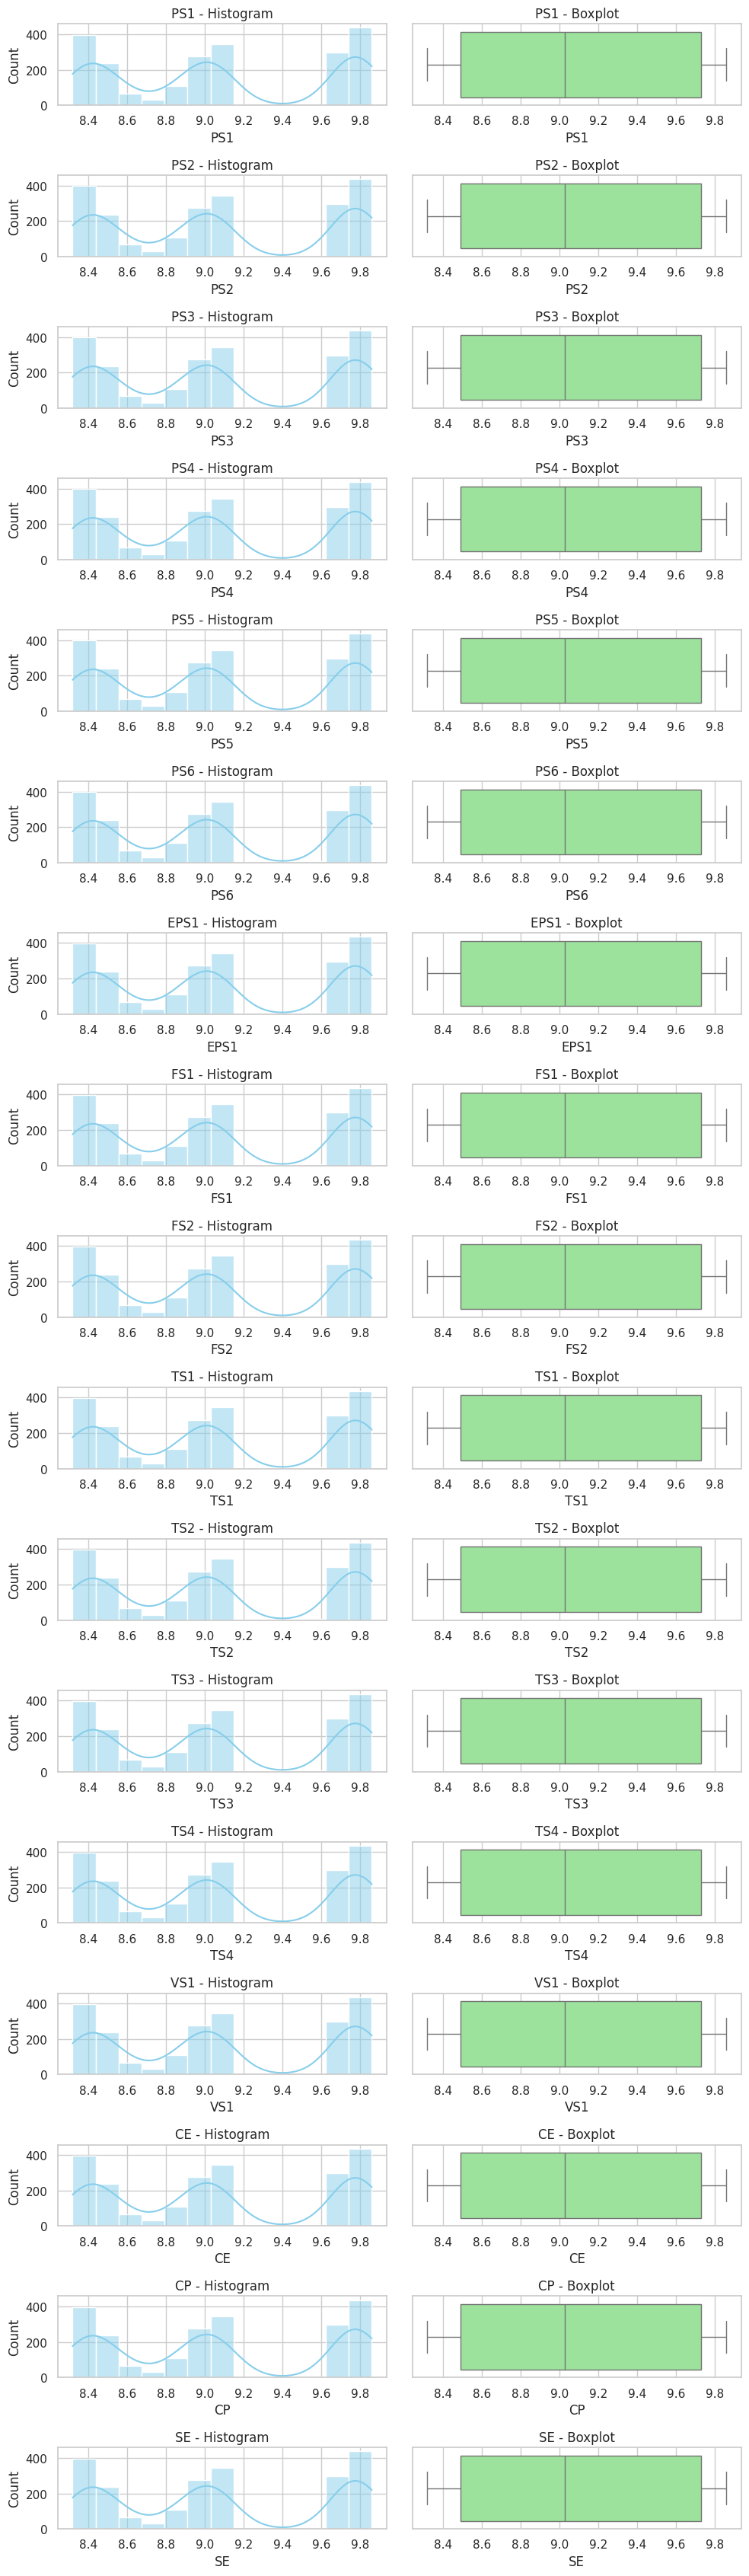

In [99]:
# List of numeric columns to plot
columns = ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1', 'FS1', 'FS2',
           'TS1', 'TS2', 'TS3', 'TS4', 'VS1', 'CE', 'CP', 'SE']

n_cols = 2  # Number of columns in subplot grid
n_rows = len(columns)  # One row per feature (hist + box)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2 * n_rows))

for i, col in enumerate(columns):
    # Histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram')

    # Boxplot (horizontal)
    sns.boxplot(data=df, x=col, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

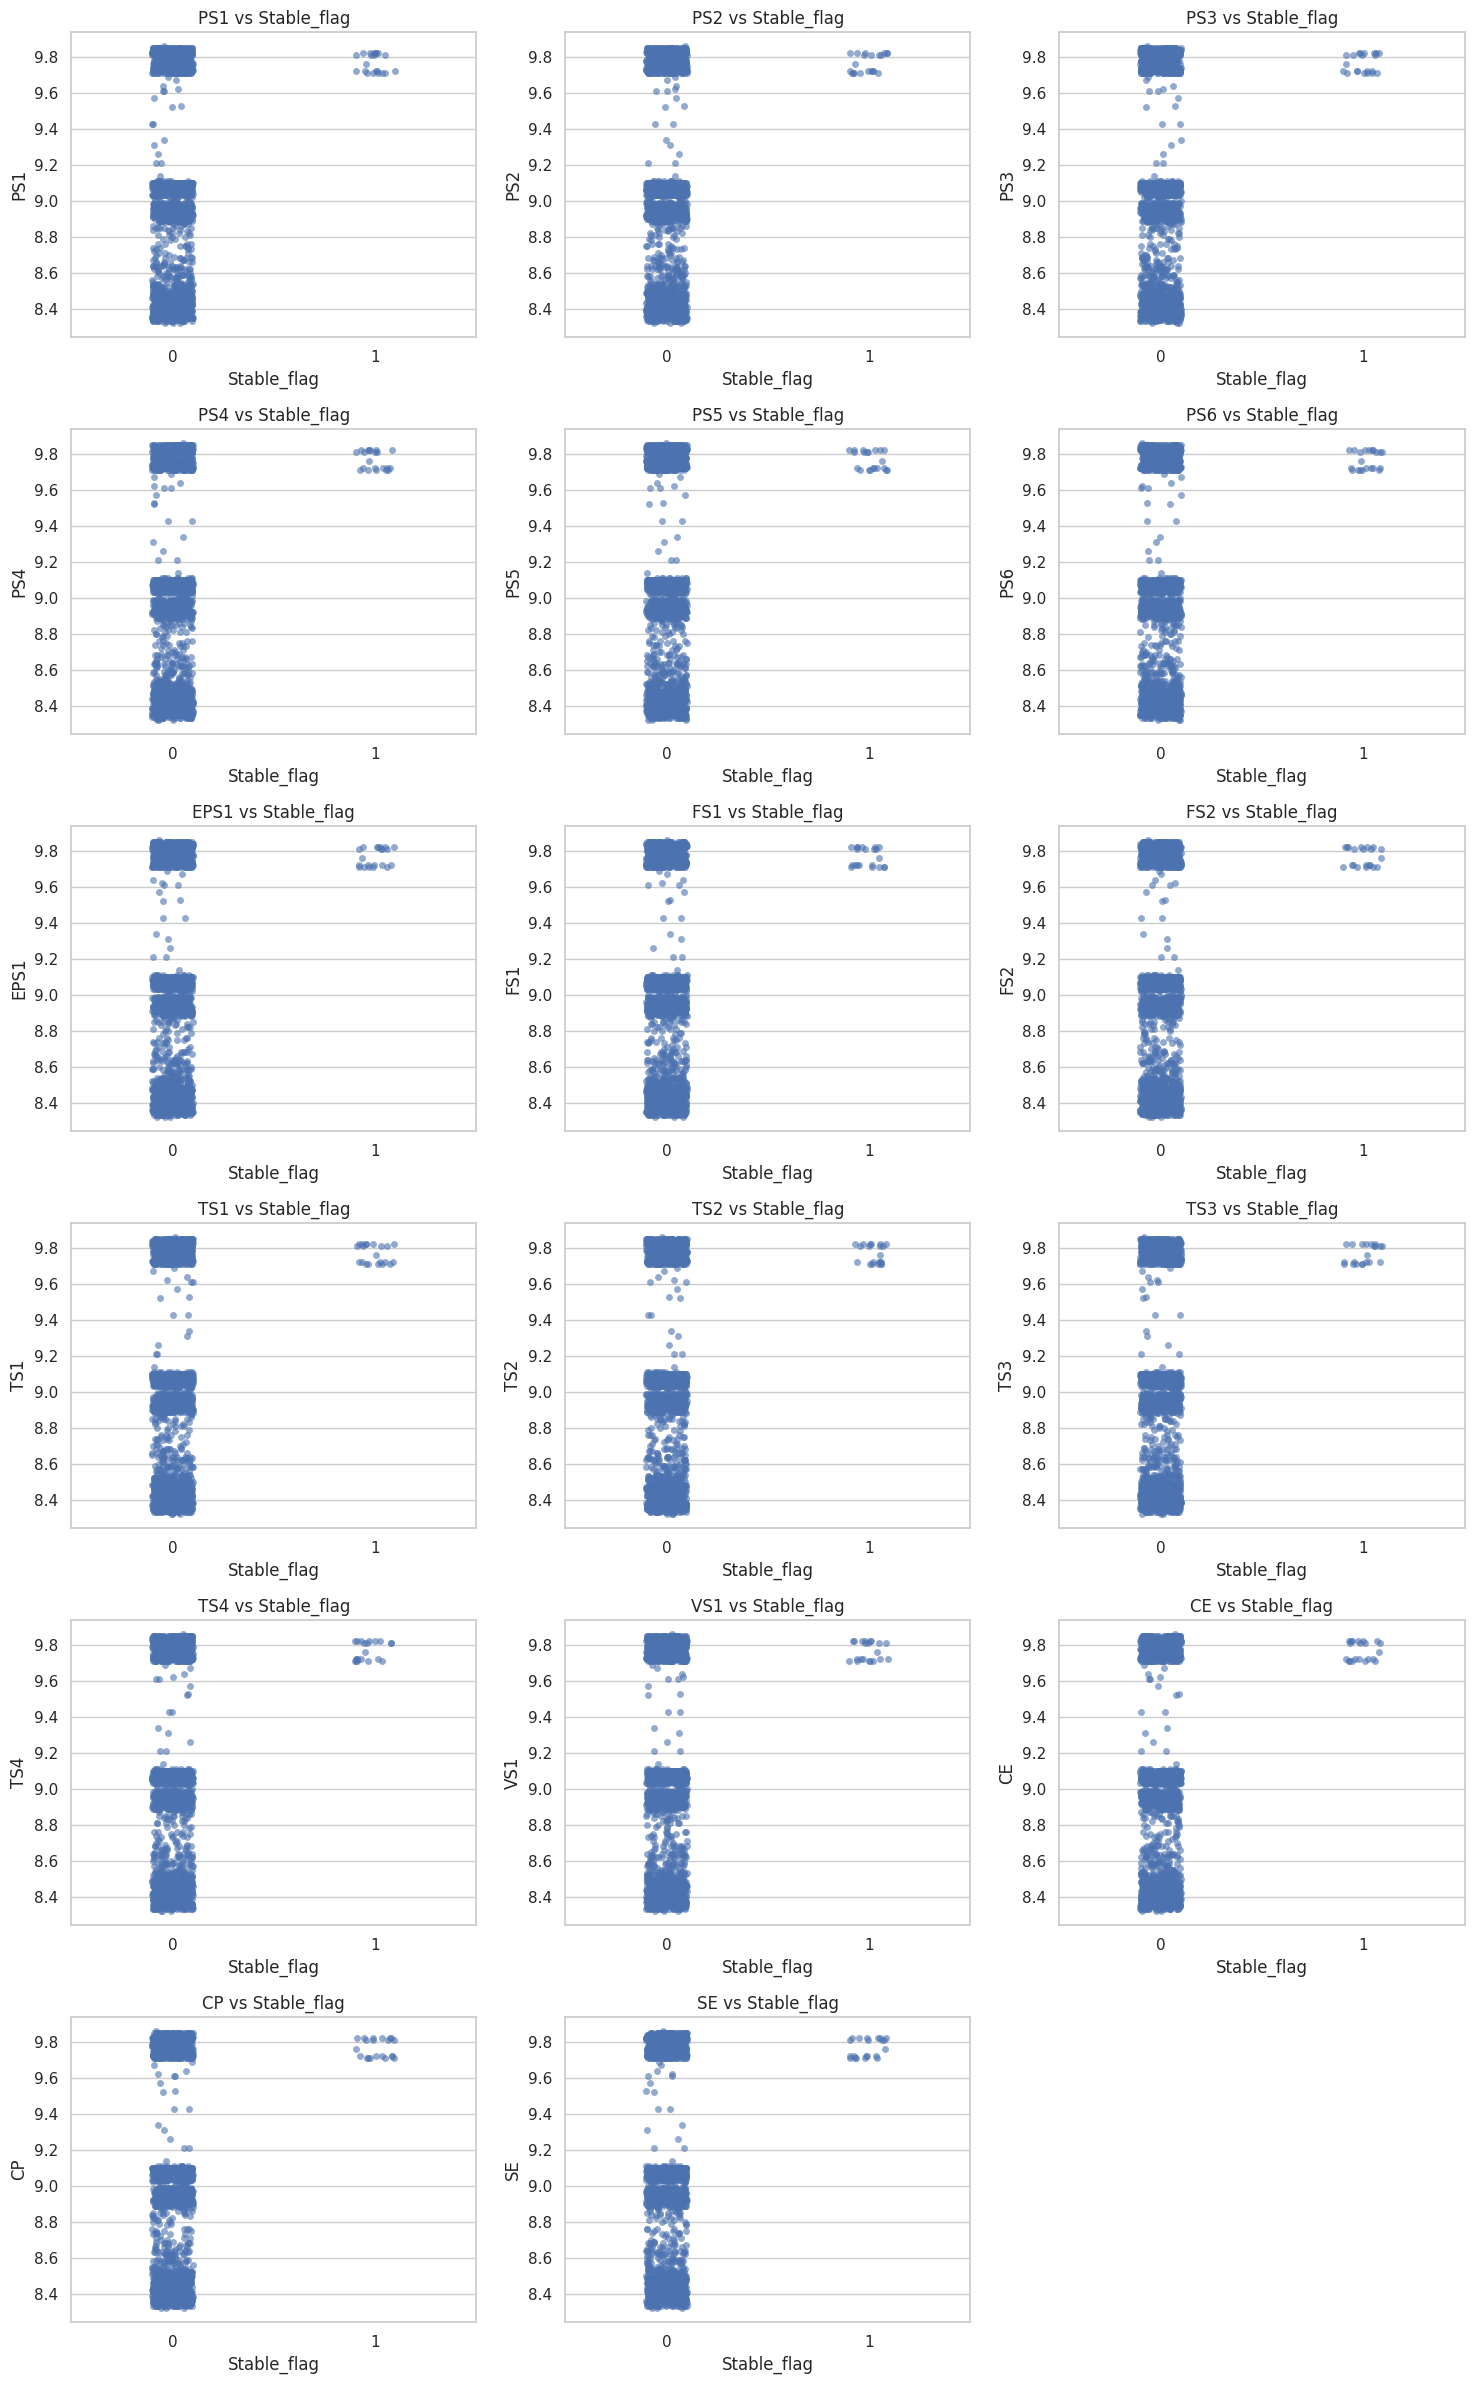

In [100]:
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# Flatten axes for easy indexing
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.stripplot(x='Stable_flag', y=col, data=df, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'{col} vs Stable_flag')

# Turn off extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

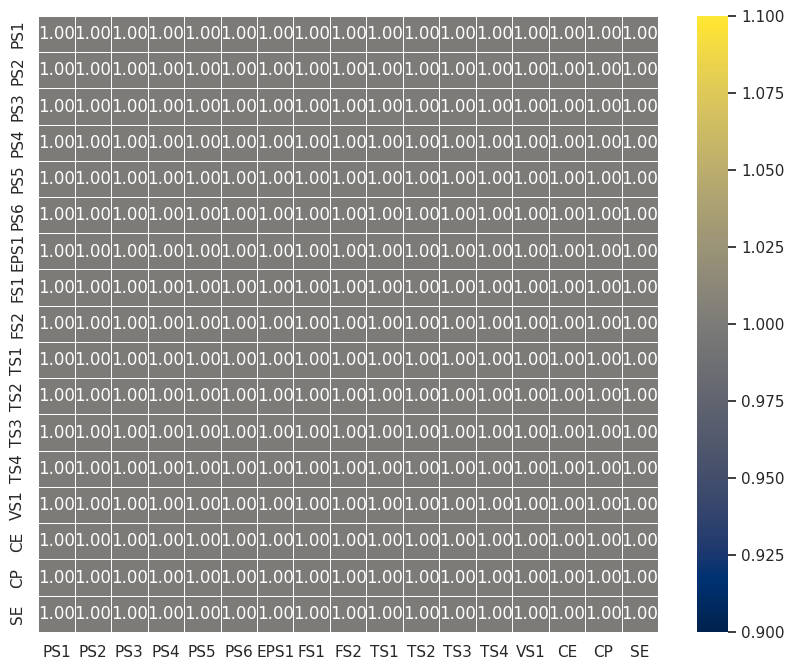

In [101]:
# Generating heatmap (numerical columns only)
corr_matrix=df[columns].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='cividis',fmt=".2f", linewidths=0.5)
plt.show()

# Data Processing

In [102]:
import pickle
from sklearn.preprocessing import StandardScaler

In [103]:
# Scaling the numerical columns
scaler = StandardScaler()
df[columns] = scaler.fit_transform(df[columns])

In [104]:
# Saving the scaling parameters
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [105]:
# Converting the categorical columns to integer type
cols = ['Cooler_condition', 'Valve_condition', 'Internal_pump_leakage', 'Hydraulic_accumulator/bar', 'Stable_flag']
for i in cols:
  df[i] = df[i].astype('int64')

In [106]:
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,...,TS4,VS1,CE,CP,SE,Cooler_condition,Valve_condition,Internal_pump_leakage,Hydraulic_accumulator/bar,Stable_flag
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,...,1.184389,1.184389,1.184389,1.184389,1.184389,3,100,0,130,0
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,...,0.820365,0.820365,0.820365,0.820365,0.820365,3,100,0,130,0
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,...,0.638354,0.638354,0.638354,0.638354,0.638354,3,100,0,130,0
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,...,0.474543,0.474543,0.474543,0.474543,0.474543,3,100,0,130,0
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,...,0.328934,0.328934,0.328934,0.328934,0.328934,3,100,0,130,0


# Model Training

In [107]:
# === BUAT ULANG CSV: data_prediksi.csv (FITUR + id) ===
# Jalankan setelah variabel `df` sudah ada di notebook.

import numpy as np
import pandas as pd
import pickle
import os

# -----------------------------
# 1) KONFIGURASI
# -----------------------------
# Kalau kamu sudah punya daftar fitur saat training, isi di sini (paling aman).
# Kalau None, akan ditebak dari kolom numerik selain label.
FEATURE_COLS = None
N_PRED = 200  # jumlah baris contoh yang disimpan (None = semua)

# Kolom label (hanya untuk dikecualikan dari fitur)
Y_COLS = ["Cooler_condition", "Valve_condition", "Internal_pump_leakage", "Hydraulic_accumulator/bar"]

# Nama file scaler/model untuk menyamakan urutan fitur (opsional)
PICKLE_CANDIDATES = ["scaler.pkl", "cooler_model.pkl", "valve_model.pkl", "pump_model.pkl", "accumulator_model.pkl"]

# -----------------------------
# 2) SIAPKAN ID
# -----------------------------
df = df.reset_index(drop=True)
df["id"] = np.arange(len(df))

# -----------------------------
# 3) TENTUKAN KOLOM FITUR
# -----------------------------
if FEATURE_COLS is None:
    # tebak: semua kolom numerik kecuali label + id
    guess = df.select_dtypes(include=[np.number]).columns.tolist()
    FEATURE_COLS = [c for c in guess if c not in Y_COLS and c != "id"]

# kalau kamu tidak pakai Stable_flag saat training, pastikan tidak ikut
# (hapus baris ini kalau kamu memang pakai Stable_flag)
# if "Stable_flag" in FEATURE_COLS:
#     FEATURE_COLS.remove("Stable_flag")

X_all = df[FEATURE_COLS + ["id"]].copy()  # id ikut, Streamlit bisa abaikan kolom ekstra

# -----------------------------
# 4) ALIGN URUTAN FITUR DENGAN PICKLE (OPSIONAL)
# -----------------------------
def _try_align_with_pickle(X, candidates):
    for fname in candidates:
        if os.path.exists(fname):
            try:
                with open(fname, "rb") as f:
                    obj = pickle.load(f)
                feat_in = getattr(obj, "feature_names_in_", None)
                if feat_in is not None:
                    feat_in = list(feat_in)
                    # ambil hanya fitur yang ada di X
                    inter = [c for c in feat_in if c in X.columns]
                    if inter:
                        # sisanya (mis. id) taruh di belakang
                        rest = [c for c in X.columns if c not in inter]
                        return X[inter + rest]
            except Exception as e:
                print(f"[WARN] Gagal baca {fname}: {e}")
    return X

X_all = _try_align_with_pickle(X_all, PICKLE_CANDIDATES)

# -----------------------------
# 5) SIMPAN data_prediksi.csv
# -----------------------------
out_pred = X_all.head(N_PRED) if N_PRED is not None else X_all
out_pred.to_csv("data_prediksi.csv", index=False)

print("✅ data_prediksi.csv ->", out_pred.shape)
print("Kolom:", list(out_pred.columns))

# (Opsional untuk Colab: auto-download)
try:
    from google.colab import files
    files.download("data_prediksi.csv")
except Exception:
    pass

✅ data_prediksi.csv -> (200, 19)
Kolom: ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1', 'FS1', 'FS2', 'TS1', 'TS2', 'TS3', 'TS4', 'VS1', 'CE', 'CP', 'SE', 'Stable_flag', 'id']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Now, we will use the sensor dataset & the Stable flag (that tells if the system was stable when data was collected — it's a flag for data quality, not a maintenance condition) to predict each conditions/factor from the factors dataset—namely, Cooler_condition, Valve_condition, Internal_pump_leakage, and Hydraulic_accumulator/bar—one by one.
#### Basically theses factors will tell whether we require maintenance in that specific component or not.

✅ Cooler condition:-	Tells if the cooler needs maintenance

✅ Valve condition:-	Tells if the valve needs maintenance

✅ Internal pump leakage:-	Tells if the pump is leaking (needs maintenance)

✅ Hydraulic accumulator condition:-	Tells if the accumulator is working well


## 1st Classification Model (Coller)
Where we use sensor dataset as independent data and Cooler Condition from factors dataset as dependent/target data.

In [108]:
df_model1 = pd.concat([df[columns], df[['Stable_flag', 'Cooler_condition']]], axis = 1)
df_model1.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Cooler_condition
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,3
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,3
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,3
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,3
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,3


In [109]:
# Cooler condition:
# 3: close to total failure
# 20: reduced effifiency
# 100: full efficiency
df_model1['Cooler_condition'].value_counts()

,count
Cooler_condition,
100,741
3,732
20,732


In [110]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Encoding the target column
df_model1['Cooler_condition'] = le.fit_transform(df_model1['Cooler_condition'])
df_model1.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Cooler_condition
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,0
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,0
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,0
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,0
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,0


## 2nd Classification Model (Valve)
Where we use sensor **dataset** as independent data and Valve Condition from factors dataset as dependent/target data.

In [111]:
df_model2 = pd.concat([df[columns], df[['Stable_flag', 'Valve_condition']]], axis = 1)
df_model2.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Valve_condition
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,100
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,100
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,100
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,100
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,100


In [112]:
# Valve condition:
# 100: optimal switching behavior
# 90: small lag
# 80: severe lag
# 73: close to total failure
df_model2['Valve_condition'].value_counts()

,count
Valve_condition,
100,1125
73,360
80,360
90,360


In [113]:
# Encoding the target column
df_model2['Valve_condition'] = le.fit_transform(df_model2['Valve_condition'])
df_model2.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Valve_condition
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,3
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,3
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,3
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,3
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,3


## 3rd Classification Model (Pump)
Where we use sensor dataset as independent data and Internal pump leakage from factors dataset as dependent/target data.

In [114]:
df_model3 = pd.concat([df[columns], df[['Stable_flag', 'Internal_pump_leakage']]], axis = 1)
df_model3.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Internal_pump_leakage
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,0
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,0
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,0
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,0
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,0


In [115]:
# Internal pump leakage:
# 0: no leakage
# 1: weak leakage
# 2: severe leakage
df_model3['Internal_pump_leakage'].value_counts()

,count
Internal_pump_leakage,
0,1221
2,492
1,492


## 4th Classification Model (Hydraulic_accumulator)
Where we use sensor dataset as independent data and Hydraulic accumulator/bar from factors dataset as dependent/target data.

In [116]:
df_model4 = pd.concat([df[columns], df[['Stable_flag', 'Hydraulic_accumulator/bar']]], axis = 1)
df_model4.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Hydraulic_accumulator/bar
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,130
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,130
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,130
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,130
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,130


In [117]:
# Hydraulic accumulator / bar:
# 130: optimal pressure
# 115: slightly reduced pressure
# 100: severely reduced pressure
# 90: close to total failure
df_model4['Hydraulic_accumulator/bar'].value_counts()

,count
Hydraulic_accumulator/bar,
90,808
130,599
115,399
100,399


In [118]:
# Encoding the target column
df_model4['Hydraulic_accumulator/bar'] = le.fit_transform(df_model4['Hydraulic_accumulator/bar'])
df_model4.head()

,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_flag,Hydraulic_accumulator/bar
0,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,1.184389,0,3
1,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0.820365,0,3
2,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0.638354,0,3
3,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0.474543,0,3
4,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0.328934,0,3



 ========================= TARGET: Cooler_condition =========================
acc=0.998 | f1_macro=0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       222
           1       1.00      1.00      1.00       220
           2       1.00      1.00      1.00       220

    accuracy                           1.00       662
   macro avg       1.00      1.00      1.00       662
weighted avg       1.00      1.00      1.00       662

Confusion matrix (angka) untuk Cooler_condition
[[222   0   0]
 [  0 219   1]
 [  0   0 220]]


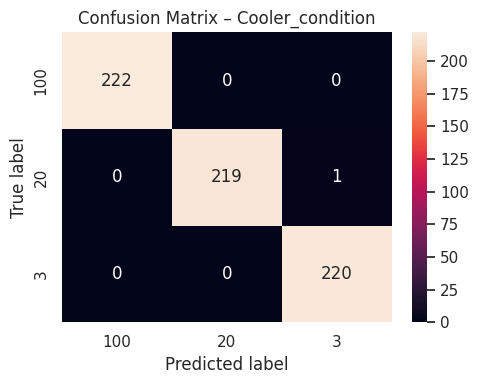

Saved → cooler_model.pkl

 ========================= TARGET: Valve_condition =========================
acc=0.834 | f1_macro=0.786
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       338
           1       0.84      0.75      0.79       108
           2       0.70      0.74      0.72       108
           3       0.67      0.74      0.70       108

    accuracy                           0.83       662
   macro avg       0.79      0.79      0.79       662
weighted avg       0.84      0.83      0.84       662

Confusion matrix (angka) untuk Valve_condition
[[311   4   0  23]
 [ 11  81  16   0]
 [  1  10  80  17]
 [  8   1  19  80]]


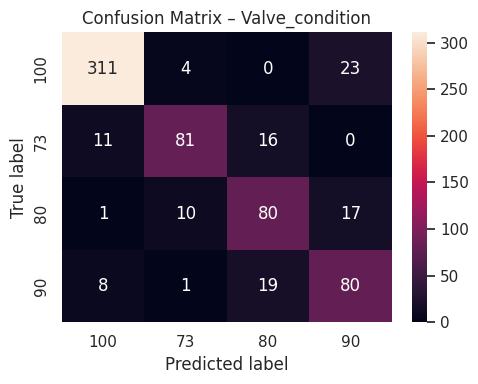

Saved → valve_model.pkl

 ========================= TARGET: Internal_pump_leakage =========================
acc=0.968 | f1_macro=0.963
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       366
           1       0.95      0.95      0.95       148
           2       0.97      0.96      0.96       148

    accuracy                           0.97       662
   macro avg       0.96      0.96      0.96       662
weighted avg       0.97      0.97      0.97       662

Confusion matrix (angka) untuk Internal_pump_leakage
[[359   7   0]
 [  3 140   5]
 [  5   1 142]]


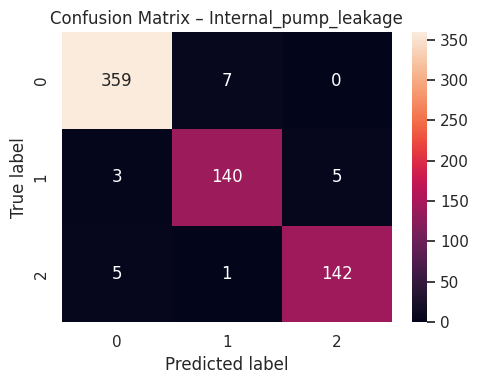

Saved → pump_model.pkl

 ========================= TARGET: Hydraulic_accumulator/bar =========================
acc=0.989 | f1_macro=0.987
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       120
           1       0.98      0.98      0.98       120
           2       0.99      0.99      0.99       180
           3       0.99      1.00      1.00       242

    accuracy                           0.99       662
   macro avg       0.99      0.99      0.99       662
weighted avg       0.99      0.99      0.99       662

Confusion matrix (angka) untuk Hydraulic_accumulator/bar
[[117   2   0   1]
 [  1 118   1   0]
 [  0   1 178   1]
 [  0   0   0 242]]


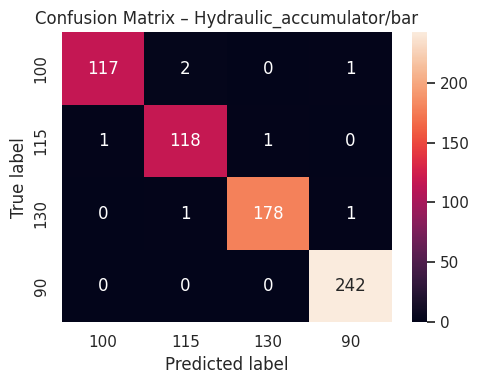

Saved → accumulator_model.pkl


In [119]:
# === HGB only: train per target & save model .pkl (fix: collapse hanya untuk split) ===
import numpy as np
import pandas as pd
import joblib
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 42

LABEL_COLS = [
    "Cooler_condition",
    "Valve_condition",
    "Internal_pump_leakage",
    "Hydraulic_accumulator/bar",
]

# guard feature_cols
if "feature_cols" not in globals():
    feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X_all = df[feature_cols].copy()

TARGETS = [
    ("Cooler_condition",            "cooler_model.pkl"),
    ("Valve_condition",             "valve_model.pkl"),
    ("Internal_pump_leakage",       "pump_model.pkl"),
    ("Hydraulic_accumulator/bar",   "accumulator_model.pkl"),
]

def to_zero_based(y_raw: pd.Series):
    s = pd.Series(y_raw).astype("object")
    classes = pd.Index(sorted(s.unique(), key=lambda x: str(x)))
    mapping = {cls: i for i, cls in enumerate(classes)}
    y_enc = s.map(mapping).astype(int).to_numpy()
    return y_enc, mapping

def collapse_rare(y_enc, min_count=2):
    y_enc = np.asarray(y_enc, dtype=int)
    counts = np.bincount(y_enc)
    major = int(np.argmax(counts))
    rare = np.where(counts < min_count)[0].tolist()
    if rare:
        y_enc = np.array([major if int(v) in rare else int(v) for v in y_enc], dtype=int)
    return y_enc

def safe_split(X, y_zb, random_state=SEED):
    counts = np.bincount(y_zb) if len(y_zb) else np.array([])
    use_strat = (len(counts) > 0) and (counts[counts > 0].min() >= 2)
    return train_test_split(
        X, y_zb, test_size=0.3, random_state=random_state,
        stratify=y_zb if use_strat else None
    )

def plot_confusion_matrix_colored(y_true, y_pred, mapping, title="Confusion Matrix"):
    """
    y_true, y_pred : label terenkripsi (0..K-1)
    mapping        : dict {label_asli: index} dari to_zero_based
    """
    inv_map = {v: k for k, v in mapping.items()}
    ordered_labels = [inv_map[i] for i in range(len(inv_map))]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=ordered_labels,
        yticklabels=ordered_labels,
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for tgt_col, out_pkl in TARGETS:
    print("\n", "="*25, f"TARGET: {tgt_col}", "="*25)

    # 1) encode label → 0..K-1
    y_raw = df[tgt_col]
    y_zb, mapping = to_zero_based(y_raw)

    if tgt_col != "Hydraulic_accumulator/bar":
        # ---------- TARGET LAIN (Cooler, Valve, Pump) ----------
        # pakai collapse_rare HANYA untuk menentukan stratify split
        y_zb_for_split = collapse_rare(y_zb, min_count=2)

        # 3) ambil index split berdasar y_zb_for_split, lalu pakai y_zb ASLI untuk train/test
        idx = np.arange(len(X_all))
        try:
            idx_tr, idx_te, y_tr_dummy, y_te_dummy = train_test_split(
                idx, y_zb_for_split, test_size=0.3, random_state=SEED, stratify=y_zb_for_split
            )
        except ValueError:
            idx_tr, idx_te, y_tr_dummy, y_te_dummy = train_test_split(
                idx, y_zb_for_split, test_size=0.3, random_state=SEED, stratify=None
            )

        X_train, X_test = X_all.iloc[idx_tr], X_all.iloc[idx_te]
        y_train, y_test = y_zb[idx_tr], y_zb[idx_te]   # LATIH & EVALUASI DENGAN LABEL ASLI

        # 4) model
        clf = HistGradientBoostingClassifier(
            max_iter=400,
            learning_rate=0.08,
            random_state=SEED
        )

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

    else:
        # ---------- KHUSUS ACCUMULATOR ----------
        X_train, X_test, y_train, y_test = safe_split(X_all, y_zb, random_state=SEED)

        clf = HistGradientBoostingClassifier(
            max_iter=650,
            learning_rate=0.06,
            max_depth=None,
            random_state=SEED
        )

        cnt = Counter(y_train)
        w = np.array([1.0 / cnt[int(y)] for y in y_train])

        clf.fit(X_train, y_train, sample_weight=w)
        y_pred = clf.predict(X_test)

    # --- METRIK (encoded) ---
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)
    print(f"acc={acc:.3f} | f1_macro={f1m:.3f}")
    print(classification_report(y_test, y_pred, digits=2, zero_division=0))

    # === CONFUSION MATRIX (angka + heatmap) ===
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix (angka) untuk", tgt_col)
    print(cm)

    plot_confusion_matrix_colored(
        y_test,
        y_pred,
        mapping,
        title=f"Confusion Matrix – {tgt_col}"
    )

    # 6) simpan model + metadata
    clf.feature_names_in_ = np.array(feature_cols)
    clf.label_mapping_ = mapping
    joblib.dump(clf, out_pkl)
    print(f"Saved → {out_pkl}")


In [120]:
import os, zipfile, datetime

# ==== 1) Daftar file yang mau di-zip ====
files_to_zip = [
    "accumulator_model.pkl",
    "cooler_model.pkl",
    "pump_model.pkl",
    "valve_model.pkl",
    "scaler.pkl",
    "data_prediksi.csv",
    "data_eval.csv",
]

# (opsional) folder yang mau ikut dimasukkan seluruh isinya
folders_to_zip = [
    # "sample_data",   # <- un-comment kalau mau ikut
    # "data",          # <- un-comment kalau mau ikut
]

# ==== 2) Nama ZIP dengan timestamp ====
zip_name = f"sempro_bundle_{datetime.datetime.now():%Y%m%d_%H%M%S}.zip"

# ==== 3) Buat ZIP ====
def add_folder(zf: zipfile.ZipFile, folder: str, base: str = "."):
    for root, _, files in os.walk(folder):
        for fn in files:
            fp = os.path.join(root, fn)
            arc = os.path.relpath(fp, start=base)  # path di dalam ZIP
            zf.write(fp, arcname=arc)

with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    # file-file individual
    for f in files_to_zip:
        if os.path.exists(f):
            zf.write(f, arcname=f)
        else:
            print(f"[skip] tidak ditemukan: {f}")
    # folder (jika diaktifkan)
    for folder in folders_to_zip:
        if os.path.isdir(folder):
            add_folder(zf, folder)
        else:
            print(f"[skip] folder tidak ditemukan: {folder}")

print("✅ ZIP dibuat:", zip_name)

# ==== 4) (Opsional Colab) auto-download ====
try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    pass


[skip] tidak ditemukan: data_eval.csv
✅ ZIP dibuat: sempro_bundle_20261001_075255.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [121]:
import joblib
import numpy as np

MODELS = [
    ("Cooler",      "cooler_model.pkl"),
    ("Valve",       "valve_model.pkl"),
    ("Pump",        "pump_model.pkl"),
    ("Accumulator", "accumulator_model.pkl"),
]

for name, path in MODELS:
    clf = joblib.load(path)
    print(f"\n=== {name} ({path}) ===")

    # 1) kelas hasil training versi indeks (0..K-1)
    if hasattr(clf, "classes_"):
        print("classes_ (index):", clf.classes_)

    # 2) mapping label asli -> index (yang kita simpan di training)
    mapping = getattr(clf, "label_mapping_", None)
    if mapping is not None:
        print("label_mapping_ (asli -> index):", mapping)

        # kalau mau lihat urutan label aslinya sesuai index:
        inv = {v: k for k, v in mapping.items()}
        ordered = [inv[i] for i in range(len(inv))]
        print("label asli (urut index 0..K-1):", ordered)
    else:
        print("⚠️ label_mapping_ tidak ada di model ini.")



=== Cooler (cooler_model.pkl) ===
classes_ (index): [0 1 2]
label_mapping_ (asli -> index): {100: 0, 20: 1, 3: 2}
label asli (urut index 0..K-1): [100, 20, 3]

=== Valve (valve_model.pkl) ===
classes_ (index): [0 1 2 3]
label_mapping_ (asli -> index): {100: 0, 73: 1, 80: 2, 90: 3}
label asli (urut index 0..K-1): [100, 73, 80, 90]

=== Pump (pump_model.pkl) ===
classes_ (index): [0 1 2]
label_mapping_ (asli -> index): {0: 0, 1: 1, 2: 2}
label asli (urut index 0..K-1): [0, 1, 2]

=== Accumulator (accumulator_model.pkl) ===
classes_ (index): [0 1 2 3]
label_mapping_ (asli -> index): {100: 0, 115: 1, 130: 2, 90: 3}
label asli (urut index 0..K-1): [100, 115, 130, 90]
